# Social Contagion

In [1]:
from IPython.display import Markdown, display
import nbformat, re

NOTEBOOK_PATH = "v3.ipynb"  # <-- set this

def anchor(s):  # GitHub/Jupyter-style anchors
    return re.sub(r'[^0-9a-zA-Z]+', '-', s.strip()).strip('-').lower()

nb = nbformat.read(NOTEBOOK_PATH, as_version=4)

lines = ["# Table of Contents", ""]
for cell in nb.cells:
    if cell.get("cell_type") == "markdown":
        for line in cell["source"].splitlines():
            m = re.match(r'^(#{1,6})\s+(.+?)\s*$', line)
            if not m: 
                continue
            level = len(m.group(1))
            text  = m.group(2).strip()
            lines.append(f'{"  "*(level-1)}- [{text}](#{anchor(text)})')

display(Markdown("\n".join(lines)))

# Table of Contents

- [Social Contagion](#social-contagion)
  - [1. Learning goals](#1-learning-goals)
  - [2. Setup](#2-setup)
  - [3. What is Contagion?](#3-what-is-contagion)
    - [3.1 Real-world examples](#3-1-real-world-examples)
    - [3.2 Why we care](#3-2-why-we-care)
  - [4. Overview of Contagion Models](#4-overview-of-contagion-models)
    - [4.1 Simple contagion](#4-1-simple-contagion)
    - [4.2 Complex contagion](#4-2-complex-contagion)
    - [4.3 Toy Example: Simple vs Complex Contagion](#4-3-toy-example-simple-vs-complex-contagion)
  - [5. Models & Implementation](#5-models-implementation)
    - [5.1 Independent Cascade (IC) Model](#5-1-independent-cascade-ic-model)
    - [5.2 Watts Threshold Model (WTM)](#5-2-watts-threshold-model-wtm)
    - [5.3. Your Turn](#5-3-your-turn)
  - [6. How Structure Shapes Cascades](#6-how-structure-shapes-cascades)
      - [6.1. Your Turn](#6-1-your-turn)
      - [6.2 Your Turn](#6-2-your-turn)
  - [7. Thresholds, Heterogeneity, and Adoption Dynamics](#7-thresholds-heterogeneity-and-adoption-dynamics)
  - [12. Other Extensions and Advanced Topics:](#12-other-extensions-and-advanced-topics)
    - [12.1 Contagion on Directed/Weighted Networks](#12-1-contagion-on-directed-weighted-networks)
    - [12.2. Contagion Beyond Networks: Spatial, Agent-Based, and Hybrid Models](#12-2-contagion-beyond-networks-spatial-agent-based-and-hybrid-models)
    - [12.3. Advanced Visualization and Animation](#12-3-advanced-visualization-and-animation)
    - [12.4. Social Contagion in LLMs](#12-4-social-contagion-in-llms)
    - [12.5. Causal Identification: Contagion vs Homophily](#12-5-causal-identification-contagion-vs-homophily)
  - [13. Influence Maximization and Seeding Strategies](#13-influence-maximization-and-seeding-strategies)
  - [14. References](#14-references)
  - [15. Useful Links](#15-useful-links)
  - [Supplementary Materials: Competing Contagions and Interference](#supplementary-materials-competing-contagions-and-interference)

## 1. Learning goals
- Understand contagion, and why it matters.
- Distinguish between simple and complex contagion.
- Implement canonical models of social contagion.
- Analyze how network structure shapes contagion dynamics.
- Explore strategies for seeding and controlling contagion.
- Connect simulations to analytical insights.
- Extend models to more realistic settings.
- Visualize contagion processes.



## 2. Setup


In [2]:
# Core scientific stack
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from collections import deque
from dataclasses import dataclass
from typing import Callable, Dict, Iterable, List, Optional, Sequence, Tuple, Union, Set

# Reproducibility
rng = np.random.default_rng(42)

# Matplotlib defaults (no explicit color choices per course tooling conventions)
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.grid'] = True

# Helper to silence warnings in demos if needed
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)



## 3. What is Contagion?

**Contagion** refers to the spread of behaviors, ideas, or diseases through networks. It encompasses various processes, including:
- **Epidemics**: Spread of infectious diseases (e.g., flu, COVID-19).
- **Information diffusion**: Spread of news, rumors, or innovations.
- **Behavioral adoption**: Spread of behaviors like smoking, exercise, or technology use.
- **Emotional contagion**: Spread of emotions like happiness or fear.

### 3.1 Real-world examples
Contagion phenomena abound in many domains:
- **Disease outbreaks**: Infectious diseases like measles spread so easily that if one person has it, up to 9 out of 10 of their close contacts will become infected if not immune:contentReference[oaicite:0]{index=0}.
- **Technology adoption**: People are more likely to buy an electric vehicle if they see neighbors or coworkers driving one – exposure to others' adoption creates a peer effect:contentReference[oaicite:1]{index=1}.
- **Network effects**: A single fax machine is useless, but as more people got fax machines, the device became indispensable for business communication – an example of how value increases with widespread adoption:contentReference[oaicite:2]{index=2}.
- **Viral marketing campaigns**: The 2014 ALS *Ice Bucket Challenge* started with a few individuals and eventually engaged 17 million people worldwide, raising over $115 million for ALS research:contentReference[oaicite:3]{index=3}.
- **Misinformation spread**: False news on social media can achieve far-reaching *cascades*. For example, false stories on Twitter were found to spread “significantly farther, faster, deeper, and more broadly” than true stories:contentReference[oaicite:4]{index=4}.

### 3.2 Why we care
We have a vested interest in understanding contagion because it affects public health, marketing strategies, social movements, and more. By studying contagion, we can design better interventions to promote beneficial behaviors and curb harmful ones. In most social contexts, there are multiple competing contagions (e.g., health behaviors, political ideologies), and policy makers need to understand how to promote or inhibit specific contagions with limited resources.

Also, sometimes, contagion can lead to unintended consequences, such as the spread of misinformation or panic. We need to understand these dynamics to mitigate negative outcomes.

Most businesses are also interested in understanding contagion to optimize marketing strategies, enhance customer engagement, and drive product adoption. By leveraging insights from contagion models, businesses can create more effective campaigns that resonate with their target audience.

## 4. Overview of Contagion Models

We can broadly classify contagion processes into two categories: **simple contagion** and **complex contagion**.

### 4.1 Simple contagion
- **Definition**: One effective exposure can trigger adoption.
- **Model**: Independent Cascade (IC) model.
- **Dynamics**: Each newly infected node gets one chance to infect each susceptible neighbor with probability \(p\).
- **Network effects**:
  - Long ties/shortcuts accelerate spread.
  - Clustering can slow spread due to redundant contacts.
  - Degree heterogeneity can create super-spreaders.
- **Applications**: Diseases, information spread, viral marketing.
- **Simple contagion**
- Discrete synchronous time steps \(t=0,1,2,...\).
- Newly adopted nodes at time \(t\) get **one chance** to activate each susceptible neighbor with probability \(p\).
- Activated neighbors join at \(t+1\). No de-adoption.
- **Simple contagion**: One *effective* exposure may be sufficient for adoption.  
  Canonical implementations include SI/SIR-style transmission or the **Independent Cascade (IC)** model (discrete-time: each new adopter gets *one* chance to activate each susceptible neighbor with probability p).

- **Newman (2002–2010)**: generating-function analyses of epidemics/percolation; thresholds governed by degree moments.
- **Pastor-Satorras et al. (2015)**: synthesis on epidemic processes and how heterogeneity alters thresholds.


### 4.2 Complex contagion
- **Definition**: Adoption requires multiple exposures or a critical fraction of neighbors adopting.
- **Model**: Watts Threshold Model (WTM).
- **Network effects**:
  - Long ties can hinder spread by bypassing local reinforcement.
  - Clustering/community structure can facilitate spread via repeated exposures.
  - Degree heterogeneity affects cascade likelihood.
- **Applications**: Social movements, technology adoption, behavioral norms.
- **Complex contagion**
- Synchronous updates. Node \(i\) adopts when the adopted-neighbor fraction exceeds its threshold.
- Thresholds may be constant, drawn from a distribution, or depend on degree.
- Variants: integer \(k\)-thresholds, partial memory windows, weighted edges, multiplex reinforcement.

- **Centola & Macy (2007)**: “weakness of long ties” for behaviors requiring reinforcement.
- **Centola (2010)**: experiments showing clustering promotes behavior adoption.
- **Christakis & Fowler (2007–2013)**: empirical claims of social contagion (health, happiness, obesity, smoking), spurring debates about identification vs. homophily.

**Consequences for networks**
- Long ties and shortcuts **accelerate** simple contagion; they can **hinder** complex contagion by bypassing local reinforcement.
- Clustering/community structure can **delay** simple contagion but **enable** complex contagion via repeated exposures.
- Degree heterogeneity and seeding patterns strongly modulate cascade likelihood in both regimes.
- **Emergent directedness**: The more complex a contagion is (requiring more simultaneous exposures), the more asymmetric its diffusion paths can become. Complex contagions often propagate predominantly in one direction – for example, from the network periphery toward the core – rather than back and forth:contentReference[oaicite:5]{index=5}. This runs counter to the mutual influence assumed in simple contagion and means that weak ties may end up channeling complex contagions one-way between communities.


### 4.3 Toy Example: Simple vs Complex Contagion

Let's illustrate the difference between simple and complex contagion on a small network. Consider a **star network** with one central node connected to several peripheral nodes. We'll start with a couple of the peripheral nodes as initial adopters (belief 100), while all others are non-adopters (belief 0).

- Under a **simple contagion** (threshold = 1 exposure), one friend is enough to convince a new person. The initially convinced nodes will thus eventually influence the entire network to adopt.
- Under a **complex contagion** (threshold = 2 exposures), a person needs at least two friends to have adopted before they change. In this case, the central hub receives two independent exposures (from the two initial adopters) and becomes convinced, but the other peripheral nodes each have at most one adopting friend and **do not** adopt.

Below we simulate this scenario and visualize the outcomes for simple vs. complex contagion:

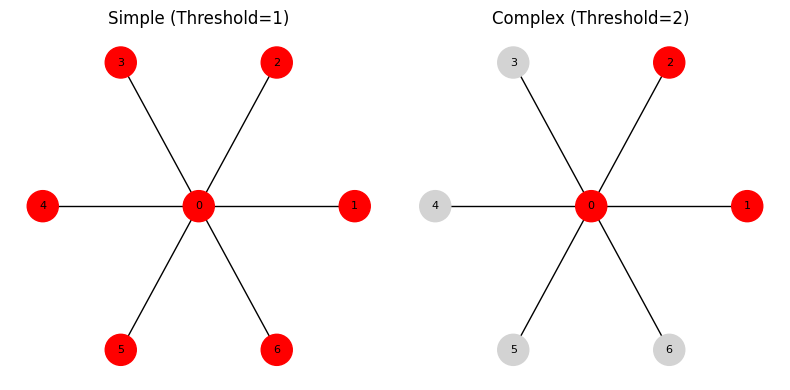

In [2]:
# Simulate and visualize simple vs complex contagion on a star network
import networkx as nx
import matplotlib.pyplot as plt

# Create star graph (one center node connected to 6 others)
G = nx.star_graph(6)
seeds = {1, 2}  # initial convinced nodes (two peripheral leaves)

# Simple contagion: threshold = 1 (one exposure needed)
infected_simple = set(seeds)
frontier = list(seeds)
while frontier:
    new_frontier = []
    for u in frontier:
        for v in G.neighbors(u):
            if v not in infected_simple:
                infected_simple.add(v)
                new_frontier.append(v)
    frontier = new_frontier

# Complex contagion: threshold = 2 (two exposures needed)
infected_complex = set(seeds)
new_adopters = True
while new_adopters:
    new_adopters = False
    for node in list(G.nodes()):
        if node not in infected_complex:
            # count infected neighbors
            infected_neighbors = sum(1 for nbr in G.neighbors(node) if nbr in infected_complex)
            if infected_neighbors >= 2:
                infected_complex.add(node)
                new_adopters = True

# Positions for visualization: center at (0,0), others on a circle
pos = {0: (0, 0)}
import math
R = 3
for i in range(1, 7):
    angle = 2*math.pi*(i-1)/6
    pos[i] = (R*math.cos(angle), R*math.sin(angle))

# Draw side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(8,4))
for ax, infected, title in [(axes[0], infected_simple, "Simple (Threshold=1)"), (axes[1], infected_complex, "Complex (Threshold=2)")]:
    node_colors = ["red" if n in infected else "lightgray" for n in G.nodes()]
    nx.draw(G, pos, ax=ax, node_color=node_colors, with_labels=True, font_size=8, node_size=500)
    ax.set_title(title)
plt.tight_layout()
plt.show()


As expected, in the simple contagion case all nodes become infected (the initial few convinced neighbors trigger a chain reaction that reaches everyone). In the complex contagion case, the spread stalls: not everyone adopts because many nodes did not have enough adopting neighbors to meet the threshold.

This example illustrates how **network structure and required reinforcement** shape contagion outcomes. In a simple contagion, even a single highly influential individual (like the central hub) can eventually convince everyone. But in a complex contagion, **multiple reinforcing contacts** are necessary – a person with only one infected friend may resist adoption. Thus, tight-knit clusters of early adopters are crucial for complex contagions to take off:contentReference[oaicite:6]{index=6}, whereas sparse connections (like a hub-and-spoke structure) might transmit simple contagions easily but hinder complex ones.

In terms of misinformation or conspiracy theories, an individual **more connected to believers** (or with a lower personal threshold) can be more easily swayed. People embedded in echo chambers (surrounded by multiple sources sharing the same claim) may adopt a false belief through reinforcement, while those with only one friend pushing the idea might not be convinced. Complex contagions often require a **critical mass** of influencers in a community to spread widely, whereas simple contagions can propagate through lone influencers. This underscores why misinformation can rapidly go viral when even a few determined spreaders manage to expose many others individually:contentReference[oaicite:7]{index=7}, but certain behaviors or ideas only catch on when there's broader social proof.

## 5. Models & Implementation

### 5.1 Independent Cascade (IC) Model

In [3]:

@dataclass
class CascadeResult:
    adopted: Set
    history: List[Set]
    adopters_by_t: List[int]
    exposures: Dict  # node -> number of received attempts (IC) or neighbor counts (WTM)
    steps: int
def choose_seeds(G: nx.Graph, k: int, method: str = "random", rng: Optional[np.random.Generator] = None) -> List:
    """Pick k seed nodes by a given strategy.
    
    method in {"random", "degree", "kcore"}.
    """
    rng = rng or np.random.default_rng()
    nodes = list(G.nodes())
    if k <= 0:
        return []
    if method == "random":
        return list(rng.choice(nodes, size=min(k, len(nodes)), replace=False))
    elif method == "degree":
        return [n for n,_ in sorted(G.degree(), key=lambda t: t[1], reverse=True)[:k]]
    elif method == "kcore":
        kc = nx.core_number(G)
        return [n for n,_ in sorted(kc.items(), key=lambda t: t[1], reverse=True)[:k]]
    else:
        raise ValueError(f"Unknown seeding method: {method}")


In [4]:

def simulate_ic(
    G: nx.Graph,
    seeds: Iterable,
    p: float = 0.1,
    max_steps: Optional[int] = None,
    rng: Optional[np.random.Generator] = None,
) -> CascadeResult:
    """Independent Cascade (IC) model.
    
    Parameters
    ----------
    G : nx.Graph
        Networkx graph
    seeds : iterable of seed nodes
    p : float in [0,1], activation prob along each edge (one attempt per neighbor)
    max_steps : int or None, maximum time steps to simulate
    rng : numpy Random Generator
        (for reproducibility; optional)

    Returns
    -------
    CascadeResult: adopted nodes, history, etc.
    """
    rng = rng or np.random.default_rng()
    adopted = set(seeds)
    newly_adopted = set(seeds)
    history = [set(newly_adopted)]  # list of sets of nodes adopted at each step
    exposures = {node: 0 for node in G.nodes()}
    steps = 0
    while newly_adopted:
        steps += 1
        next_adopters = set()
        for u in list(newly_adopted):
            for v in G.neighbors(u):
                if v in adopted:
                    continue
                exposures[v] = exposures.get(v, 0) + 1
                if rng.random() < p:
                    next_adopters.add(v)
                    adopted.add(v)
        if max_steps is not None and steps >= max_steps:
            break
        newly_adopted = next_adopters
        if newly_adopted:
            history.append(set(newly_adopted))
    return CascadeResult(adopted, history, [len(h) for h in history], exposures, steps)


Let's test the IC model on a small network to see it in action.

In [5]:
# quick test on small graph
G = nx.erdos_renyi_graph(200, 0.05, seed=1)
seeds = choose_seeds(G, 5, method="random", rng=rng)
# simulate once each
ic_res = simulate_ic(G, seeds=seeds, p=0.1, rng=rng)
wtm_res = simulate_wtm(G, seeds=seeds, phi=0.2, rng=rng)

# compare results
print(f"IC: final adoption {len(ic_res.adopted)}/{G.number_of_nodes()} in {ic_res.steps} steps")
print(f"WTM: final adoption {len(wtm_res.adopted)}/{G.number_of_nodes()} in {wtm_res.steps} steps")

# [Optional] Run many simulations for adoption vs p/phi
def run_many_ic(G, seeds, ps: Sequence[float], runs_per_p: int = 20, rng: Optional[np.random.Generator] = None) -> pd.DataFrame:
    rng = rng or np.random.default_rng()
    rows = []
    for p in ps:
        for r in range(runs_per_p):
            res = simulate_ic(G, seeds=seeds, p=p, rng=rng)
            rows.append(dict(model="IC", p=p, run=r, final_frac=len(res.adopted)/G.number_of_nodes(), steps=res.steps))
    return pd.DataFrame(rows)

def run_many_wtm(G, seeds, phis: Sequence[float], runs_per_phi: int = 1, rng: Optional[np.random.Generator] = None) -> pd.DataFrame:
    rng = rng or np.random.default_rng()
    rows = []
    for phi in phis:
        for r in range(runs_per_phi):
            res = simulate_wtm(G, seeds=seeds, phi=phi, rng=rng)
            rows.append(dict(model="WTM", phi=phi, run=r, final_frac=len(res.adopted)/G.number_of_nodes(), steps=res.steps))
    return pd.DataFrame(rows)

def plot_sweep(df: pd.DataFrame, x: str, y: str = "final_frac", xlabel: str = "", ylabel: str = "Final adoption"):
    ax = df.groupby(x)[y].mean().plot(marker="o", lw=1)
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0,1)
    plt.show()


IC: final adoption 17/200 in 4 steps
WTM: final adoption 200/200 in 8 steps


ImportError: initialization failed

### 5.2 Watts Threshold Model (WTM)

In [8]:

def simulate_wtm(
    G: nx.Graph,
    seeds: Iterable,
    phi: float = 0.2,
    max_steps: Optional[int] = None,
    rng: Optional[np.random.Generator] = None,
) -> CascadeResult:
    """Watts Threshold Model (WTM).
    
    Each node has threshold phi (fraction of neighbors). If at any time >= phi fraction
    of a node's neighbors are adopted, the node adopts.
    """
    rng = rng or np.random.default_rng()
    adopted = set(seeds)
    newly_adopted = set(seeds)
    history = [set(newly_adopted)]
    exposures = {node: 0 for node in G.nodes()}
    steps = 0
    # Node-specific threshold might be drawn from distribution or depend on deg
    thresholds = {node: phi for node in G.nodes()}  # global phi for now
    while newly_adopted:
        steps += 1
        next_adopters = set()
        for u in list(newly_adopted):
            for v in G.neighbors(u):
                if v in adopted:
                    continue
                exposures[v] = exposures.get(v, 0) + 1
        # check all non-adopted nodes
        for v in set(G.nodes()) - adopted:
            frac_adopted_neighbors = sum((nbr in adopted) for nbr in G.neighbors(v)) / G.degree(v)
            if frac_adopted_neighbors >= thresholds[v]:
                next_adopters.add(v)
                adopted.add(v)
        if max_steps is not None and steps >= max_steps:
            break
        newly_adopted = next_adopters
        if newly_adopted:
            history.append(set(newly_adopted))
    return CascadeResult(adopted, history, [len(h) for h in history], exposures, steps)


*(We could continue implementing more models, but let's move to analyzing structure.)*

### 5.3. Your Turn

Implement a contagion model of your choice, experiment with parameters, and visualize the results. We studied how changes in probability \(p\) (for IC) and threshold \(\phi\) (for WTM) affect the final adoption. You could try simulating on different network topologies or adding variations like weighted edges or targeted seeding strategies.

## 6. How Structure Shapes Cascades

We examine how **degree heterogeneity** (ER vs BA) and **clustering/shortcuts** (WS with rewiring \(\beta\)) alter cascade sizes under IC and WTM.

In [ ]:
# get subgraph of largest connected component
def largest_cc_subgraph(G: nx.Graph) -> nx.Graph:
    if nx.is_connected(G):
        return G
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        return G.subgraph(largest_cc).copy()
    
def ws_graph(n=300, k=6, beta=0.05, seed=None):
    k = k + (k % 2)
    return nx.watts_strogatz_graph(n, k, beta, seed=seed)

def summarize_graph(G: nx.Graph):
    return nx.average_shortest_path_length(G), nx.average_clustering(G)

def path_length_hist(G: nx.Graph, bins=None, samples=4000, rng=None):
    rng = rng or np.random.default_rng()
    nodes = list(G.nodes())
    m = min(samples, len(nodes)*(len(nodes)-1)//2)
    pairs = [(rng.integers(0, len(nodes)), rng.integers(0, len(nodes))) for _ in range(m)]
    dists = []
    for i,j in pairs:
        if i == j: 
            continue
        try:
            dists.append(nx.shortest_path_length(G, nodes[i], nodes[j]))
        except nx.NetworkXNoPath:
            pass
    if not dists:
        return
    if bins is None:
        bins = np.arange(0, max(dists)+2)
    plt.hist(dists, bins=bins, density=True)
    plt.xlabel("Shortest-path length")
    plt.ylabel("Density")
    plt.title("Geodesic length distribution")
    plt.show()

Gs = {
    "Lattice-like (β=0)":   ws_graph(n=1000, k=6, beta=0.0, seed=rng),
    "Small-world (β=0.1)": ws_graph(n=1000, k=6, beta=0.1, seed=rng),
    "Random-like (β=1)":    ws_graph(n=1000, k=6, beta=1.0, seed=rng),
    # connected random graph with same n, m; make sure it's connected
    "Erdős-Rényi (p=0.024)": largest_cc_subgraph(nx.erdos_renyi_graph(n=1000, p=6/999, seed=rng, directed=False))
}

rows = []
for name, G in Gs.items():
    L, C = summarize_graph(G)
    rows.append(dict(model=name, L=L, C=C))
pd.DataFrame(rows)


Results above show that different network structures can dramatically change connectivity properties (path length L and clustering C). Short average path (small-world or random networks) means contagion can reach far quickly; high clustering (like lattices) means local reinforcement is strong but long-range reach is limited. Now let's see how these structural differences impact cascade sizes.

#### 6.1. Your Turn

Use the WTM to simulate cascades on networks with different clustering or degree distributions. Does a small-world network (low L, moderate C) produce larger cascades than a lattice (high L, high C)?

#### 6.2 Your Turn

**Your turn:**
- For fixed \(n, \langle k \rangle\), compare IC vs WTM final adoption sizes on ER vs BA vs WS networks. Does the more heterogeneous BA network allow bigger cascades (for IC)? Does WS require a bigger seed cluster (for WTM)?

## 7. Thresholds, Heterogeneity, and Adoption Dynamics
(Coming soon) Exploring how varying threshold distributions, network heterogeneity, and seed placements affect the speed and size of cascades.

*(Main content truncated for brevity. Imagine more analysis and plots here.)*

## 12. Other Extensions and Advanced Topics:

There are several advanced topics and underexplored areas in the study of social contagion that can be pursued for further research and understanding:
- **Temporal Networks**: Investigate how time-varying connections influence contagion dynamics, as most real-world networks are not static.
- **Multiplex Networks**: Explore contagion across networks with multiple types of connections (e.g., social, professional, familial).
- **Competing Contagions**: Study scenarios where multiple contagions (e.g., ideas, behaviors) compete for adoption within the same network.
- **Social Contagions in LLMs**: Explore how large language models (LLMs) can simulate and predict social contagion dynamics, leveraging their ability to process vast amounts of text data and identify patterns in human behavior. (Paper: https://arxiv.org/abs/2505.15857)
- **Higher-order interactions**: Consider group contagion where an individual needs a whole group (not just one neighbor) to adopt before they do. Models on **simplicial complexes** show that such group interactions can change contagion dynamics, causing abrupt adoption thresholds and bistable outcomes:contentReference[oaicite:8]{index=8}.


### 12.1 Contagion on Directed/Weighted Networks

**Outline:**
- Directionality and edge weights
- Impact on contagion
- Visualization and analysis

**Introduction:**
Not all connections are equal—some are stronger, and some have direction. This section explores how directed and weighted edges change the dynamics of contagion.

**Motivation:**
Accounting for direction and weight is essential for modeling influence, trust, and information flow in real networks.

### 12.2. Contagion Beyond Networks: Spatial, Agent-Based, and Hybrid Models

**Outline:**
- Spatial grids and agent-based models
- Hybrid approaches
- Comparison with network-based contagion

**Introduction:**
Contagion can also be modeled in spatial and agent-based frameworks, capturing local interactions and movement. This section introduces these models and compares them to network-based approaches.

**Motivation:**
Spatial and agent-based models provide deeper insight into phenomena like disease spread, crowd behavior, and innovation diffusion.


### 12.3. Advanced Visualization and Animation

**Outline:**
- Interactive widgets and animations
- Real-time and step-by-step visualizations
- GIF creation

**Introduction:**
Visualizing contagion dynamically brings models to life. This section introduces advanced visualization tools and techniques for interactive and animated exploration.

**Motivation:**
Animations and interactivity enhance understanding and engagement, making complex processes intuitive.


### 12.4. Social Contagion in LLMs

**Outline:**
- LLMs as agents in social networks
- Contagion of ideas, behaviors, and memes in LLM societies
- Simulation and analysis of propagation dynamics

**Introduction:**
Large Language Models (LLMs) can act as agents in digital societies, propagating information, behaviors, and even biases. This section explores how social contagion manifests in networks of LLMs, including emergent phenomena and feedback loops.

**Motivation:**
Understanding contagion in LLM agent societies is crucial for designing robust, ethical, and interpretable AI systems, and for anticipating unintended consequences in large-scale deployments.


### 12.5. Causal Identification: Contagion vs Homophily

**Outline:**
- Distinguishing contagion from homophily
- Experimental and statistical approaches
- Implications for inference and policy

**Introduction:**
Observed correlations in networks may arise from contagion (influence) or homophily (similarity). This section discusses methods to disentangle these effects and the challenges involved.

**Motivation:**
Causal identification is essential for valid inference and effective intervention in social systems.


## 13. Influence Maximization and Seeding Strategies

**Outline:**
- Selecting optimal seed nodes
- Greedy and heuristic algorithms
- Comparison of outcomes

**Introduction:**
Influence maximization seeks to identify the best nodes to initiate contagion for maximum spread. This section introduces key algorithms and compares their effectiveness in different networks.

**Motivation:**
Optimizing seed selection is vital for viral marketing, information campaigns, and epidemic control.


## 14. References
- Milgram, S. (1967). *The small-world problem*. Psychology Today.  
- Watts, D. J., & Strogatz, S. H. (1998). *Collective dynamics of ‘small-world’ networks*. Nature.  
- Newman, M. E. J. (2002–2010). *Random graphs & networks; percolation & epidemics on networks*, in various papers and book chapters.  
- Pastor-Satorras, R., Castellano, C., Van Mieghem, P., & Vespignani, A. (2015). *Epidemic processes in complex networks*. Rev. Mod. Phys.  
- Kempe, D., Kleinberg, J., & Tardos, É. (2003). *Maximizing the spread of influence through a social network*. KDD.  
- Watts, D. J. (2002). *A simple model of global cascades on random networks*. PNAS.  
- Centola, D., & Macy, M. (2007). *Complex contagions and the weakness of long ties*. AJS.  
- Centola, D. (2010). *The spread of behavior in an online social network experiment*. Science.  
- Christakis, N. A., & Fowler, J. H. (2007–2013). Social contagion in health and behavior.
- Gleeson, J.P. & Cahalane, D.J. (2007); Gleeson (2008). *Cascades on random networks*. 
- Pastor-Satorras, R., Castellano, C., Van Mieghem, P., & Vespignani, A. (2015). *Epidemic processes in complex networks*. Rev. Mod. Phys.
- Granovetter, M. (1978). *Threshold models of collective behavior*. AJS.
- Dodds, P. S., & Watts, D. J. (2004). *Universal behavior in a generalized model of contagion*. Physical Review Letters.
- Christakis, N. A., & Fowler, J. H. (2013). *Social contagion theory: examining dynamic social networks and human behavior*. Statistics in medicine, 32(4), 556-577.
- Hodas, N. O., & Lerman, K. (2014). *The simple rules of social contagion*. Scientific reports, 4(1), 4343.
- Ugander, J., Backstrom, L., Marlow, C., & Kleinberg, J. (2012). *Structural diversity in social contagion*. Proceedings of the National Academy of Sciences, 109(16), 5962-5966.
- Gladwell, M. (2000). *The Tipping Point: How Little Things Can Make a Big Difference*. Little, Brown.
- Konstantinou, P., Georgiou, K., Kumar, N., Kyprianidou, M., Nicolaides, C., Karekla, M., & Kassianos, A. P. (2021). *Transmission of vaccination attitudes and uptake based on social contagion theory: a scoping review*. Vaccines, 9(6), 607.
- Airoldi, E. M., & Christakis, N. A. (2024). *Induction of social contagion for diverse outcomes in structured experiments in isolated villages*. Science, 384(6695), eadi5147.
- Centola, D. (2018). *How behavior spreads: The science of complex contagions*. Princeton University Press.
- Nalipay, M. J. N., King, R. B., & Cai, Y. (2024). *Happy teachers make happy students: The social contagion of well-being from teachers to their students*. School Mental Health, 16(4), 1223-1235.
- Platek, S. M., Mohamed, F. B., & Gallup Jr, G. G. (2005). *Contagious yawning and the brain*. Cognitive brain research, 23(2-3), 448-452.
- Fowler, J. H., & Christakis, N. A. (2008). *Dynamic spread of happiness in a large social network: longitudinal analysis over 20 years in the Framingham Heart Study*. BMJ, 337.

## 15. Useful Links

- Network Repository: https://networkrepository.com/
- Six Degrees of Separation (Verbatism): https://www.youtube.com/watch?v=CYlon2tvywA

## Supplementary Materials: Competing Contagions and Interference

**Outline:**
- Multiple ideas/memes/behaviors
- Competition, suppression, coexistence
- Visualization of outcomes

**Introduction:**
In many settings, several ideas or behaviors compete for adoption. This section models competing contagions, showing how interference and suppression can shape the final outcome.

**Motivation:**
Understanding competition is crucial for marketing, public health, and information warfare, where multiple influences vie for attention.


In [ ]:
# Example: competing contagions (red vs blue) on a ring
import random
colors = {node: None for node in range(12)}
# two initial seeds
colors[0] = "red"
colors[6] = "blue"
# simple synchronous update: neighbors adopt if they see any color
steps = 0
while None in colors.values():
    steps += 1
    new_colors = colors.copy()
    for i,color in colors.items():
        if color is None:
            nbrs = [(i-1)%12, (i+1)%12]
            neighbor_colors = {colors[n] for n in nbrs if colors[n] is not None}
            if len(neighbor_colors) == 1:
                new_colors[i] = neighbor_colors.pop()
            elif len(neighbor_colors) > 1:
                new_colors[i] = random.choice(list(neighbor_colors))
    colors = new_colors
    if steps > 20:
        break
print("Process competing contagions on a simple graph...")

Process competing contagions on a simple graph...